**Lab2-DL: A3-MNIST-datacollection.ipynb** (BMED365) | Priority: 3 (optional)

_Data collection, inspection, and organization of the MNIST dataset_

[![Google Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/arvidl/BMED365-2026/blob/main/Lab2-DL/notebooks/A3-MNIST-datacollection.ipynb)

Last updated: 2025-12-22, 2026-01-15  A. Lundervold

Use the `bmed365-2026` conda environment or Google Colab

---

## Introduction and Motivation

### 🎯 Learning Objectives

By the end of this notebook, you will be able to:

| Objective | Description |
|-----------|-------------|
| **Download data programmatically** | Fetch datasets using scikit-learn and torchvision |
| **Inspect data structure** | Understand shapes, types, and distributions |
| **Store data efficiently** | Use compression to reduce file sizes by 10x |
| **Compare storage formats** | CSV vs compressed CSV vs image files |
| **Apply to medical context** | See how these skills transfer to clinical datasets |

### Why MNIST?

**MNIST** (Modified National Institute of Standards and Technology) is a classic dataset for image recognition:

| Property | Value |
|----------|-------|
| **Images** | 70,000 handwritten digits (0-9) |
| **Size** | 28×28 pixels, grayscale |
| **Task** | Classification (10 classes) |
| **Use case** | Benchmark for ML algorithms |

### Why learn data collection?

In medical AI, we often work with:
- **Image files** (DICOM, PNG, JPEG) that need to be organized
- **Metadata** (patient ID, diagnosis) that must be linked to images
- **Large datasets** that require efficient storage

This notebook teaches you:
1. 📥 **Download** data programmatically
2. 🔍 **Inspect** and understand data structure
3. 💾 **Store** data efficiently (compression!)
4. 📊 **Analyze** the dataset before modeling

In [1]:
# === Check runtime environment ===
# Check if we are running in Google Colab or locally

try:
    import google.colab
    IS_COLAB = True
    print("✅ Running in Google Colab")
except ImportError:
    IS_COLAB = False
    print("💻 Running locally (not Colab)")

💻 Running locally (not Colab)


In [2]:
# === Import required libraries ===

import numpy as np              # Numerical computation
import pandas as pd             # Tabular data
import matplotlib.pyplot as plt # Visualization
import os                       # File handling
import gzip                     # Compression
from pathlib import Path        # Path handling

# PyTorch for data loading
from torchvision import datasets
import torchvision.transforms as transforms

print("✅ All libraries loaded")

✅ All libraries loaded


---

## 1. Download MNIST Data

We load MNIST as **tabular data** (flat vectors) – each image becomes a row with 784 columns (28×28 pixels).

In [3]:
# =============================================================================
# DATA LOADING FUNCTION
# =============================================================================
#
# WHY PROGRAMMATIC DATA LOADING?
# ------------------------------
# In medical AI, we need to:
#   1. Fetch data from repositories (TCIA, PhysioNet, etc.)
#   2. Handle different environments (local vs cloud)
#   3. Ensure reproducibility with fixed random seeds
#   4. Document data provenance (where did it come from?)
#
# MNIST AS A PROTOTYPE:
# ---------------------
# The same patterns apply to medical datasets:
#   - MNIST: 70,000 images, 28×28 pixels
#   - ChestX-ray14: 112,000 images, 1024×1024 pixels
#   - Same workflow: download → preprocess → store → load
#
# =============================================================================

def load_mnist_data(num_images=None, random_seed=42):
    """
    Loads the MNIST dataset as tabular data.
    
    Parameters:
    -----------
    num_images : int, optional
        Number of images to load. None = all 70,000.
    random_seed : int
        Seed for reproducibility (important for subset selection)
        
    Returns:
    --------
    X : array (n_images, 784)
        Pixel data (normalized 0-1)
    y : array (n_images,)
        Digit labels (0-9)
        
    Note:
    -----
    Uses torchvision locally, tensorflow_datasets in Colab.
    Both sources provide the same canonical MNIST dataset.
    """
    print("📥 Loading MNIST data...")
    
    if IS_COLAB:
        # Google Colab: Use tensorflow_datasets
        import tensorflow_datasets as tfds
        dataset = tfds.load('mnist', split='train+test', as_supervised=True)
        X, y = [], []
        for image, label in dataset:
            X.append(image.numpy().reshape(784))
            y.append(label.numpy())
        X = np.array(X) / 255.0
        y = np.array(y)
    else:
        # Local: Use PyTorch
        data_folder = Path('./data')
        
        mnist_train = datasets.MNIST(
            root=data_folder, train=True, download=True,
            transform=transforms.ToTensor()
        )
        mnist_test = datasets.MNIST(
            root=data_folder, train=False, download=True,
            transform=transforms.ToTensor()
        )
        
        # Convert to numpy and normalize
        X_train = mnist_train.data.numpy().reshape(60000, -1) / 255.0
        X_test = mnist_test.data.numpy().reshape(10000, -1) / 255.0
        y_train = mnist_train.targets.numpy()
        y_test = mnist_test.targets.numpy()
        
        # Combine training and test data
        X = np.concatenate([X_train, X_test])
        y = np.concatenate([y_train, y_test])
    
    total_available = len(X)
    print(f"   Total available: {total_available:,} images")
    
    # Take a random sample if desired
    if num_images is not None:
        num_images = min(num_images, total_available)
        np.random.seed(random_seed)
        indices = np.random.choice(total_available, num_images, replace=False)
        X = X[indices]
        y = y[indices]
        print(f"   Using sample: {num_images:,} images")
    
    return X, y

In [4]:
# === Load a sample of MNIST ===

NUM_IMAGES = 20000  # Adjust up to 70,000 if needed

X, y = load_mnist_data(num_images=NUM_IMAGES)

print(f"\n📊 Dataset info:")
print(f"   Shape of X: {X.shape} (images × pixels)")
print(f"   Shape of y: {y.shape} (labels)")
print(f"   Unique classes: {np.unique(y)}")

📥 Loading MNIST data...
   Total available: 70,000 images
   Using sample: 20,000 images

📊 Dataset info:
   Shape of X: (20000, 784) (images × pixels)
   Shape of y: (20000,) (labels)
   Unique classes: [0 1 2 3 4 5 6 7 8 9]


---

## 2. Visualize the Data

Let's look at some examples and average digits.

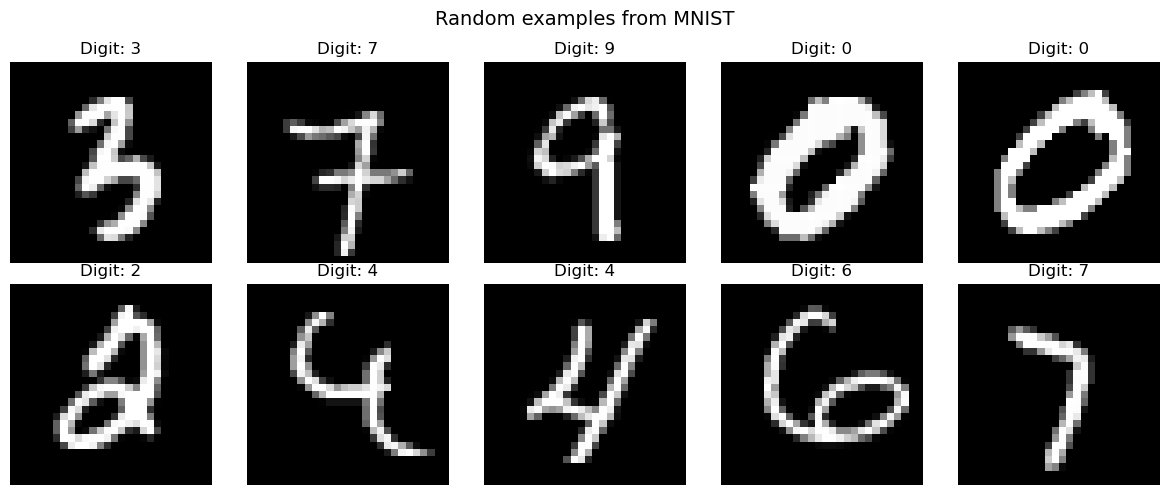

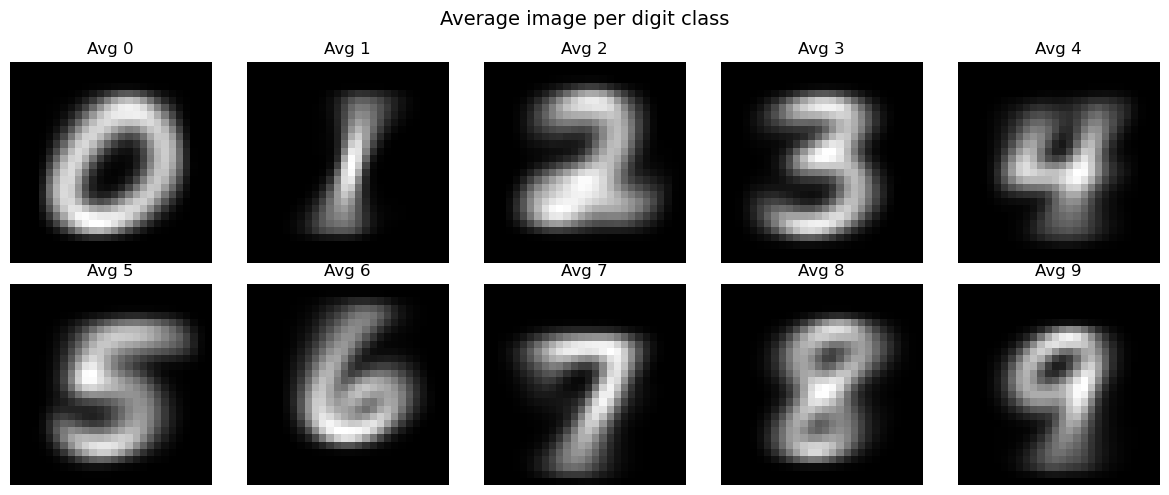

In [5]:
def show_examples(X, y, num=10):
    """Shows random examples from the dataset."""
    fig, axes = plt.subplots(2, 5, figsize=(12, 5))
    axes = axes.ravel()
    
    indices = np.random.choice(len(X), num, replace=False)
    
    for i, idx in enumerate(indices):
        image = X[idx].reshape(28, 28)
        axes[i].imshow(image, cmap='gray')
        axes[i].set_title(f'Digit: {y[idx]}', fontsize=12)
        axes[i].axis('off')
    
    plt.suptitle('Random examples from MNIST', fontsize=14)
    plt.tight_layout()
    plt.show()

def show_average_per_class(X, y):
    """Shows average image for each digit."""
    fig, axes = plt.subplots(2, 5, figsize=(12, 5))
    axes = axes.ravel()
    
    for digit in range(10):
        images_for_digit = X[y == digit]
        average = images_for_digit.mean(axis=0).reshape(28, 28)
        
        axes[digit].imshow(average, cmap='gray')
        axes[digit].set_title(f'Avg {digit}', fontsize=12)
        axes[digit].axis('off')
    
    plt.suptitle('Average image per digit class', fontsize=14)
    plt.tight_layout()
    plt.show()

# Show examples
show_examples(X, y)
show_average_per_class(X, y)

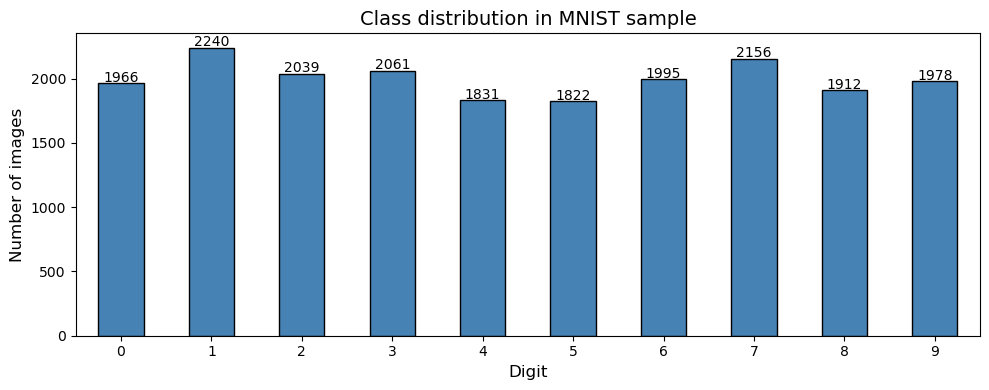


📊 Class distribution:
   Count
0   1966
1   2240
2   2039
3   2061
4   1831
5   1822
6   1995
7   2156
8   1912
9   1978


In [6]:
# === Class distribution ===

class_distribution = pd.Series(y).value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 4))
class_distribution.plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
ax.set_xlabel('Digit', fontsize=12)
ax.set_ylabel('Number of images', fontsize=12)
ax.set_title('Class distribution in MNIST sample', fontsize=14)
ax.set_xticklabels(range(10), rotation=0)

# Add numbers above the bars
for i, v in enumerate(class_distribution.values):
    ax.text(i, v + 10, str(v), ha='center', fontsize=10)

plt.tight_layout()
plt.show()

print(f"\n📊 Class distribution:")
print(class_distribution.to_frame('Count'))

---

## 3. Efficient Data Storage

### Why compression is important

In medical AI, we often handle:
- **Large image files** (MRI, CT, X-ray)
- **Many patients** (thousands of files)
- **Limited storage space** (local disk, cloud)

**Compression** can significantly reduce file size without losing information (lossless).

| Format | Description | Typical compression |
|--------|-------------|---------------------|
| `.csv` | Uncompressed text | 1× (baseline) |
| `.csv.gz` | Gzip-compressed | 5-10× smaller |
| `.parquet` | Column-based binary | 10-20× smaller |

In [7]:
# === Create DataFrame with pixel data ===

# Column names for each pixel
pixel_columns = [f'pixel_{i}' for i in range(784)]

# Create DataFrame
df = pd.DataFrame(X, columns=pixel_columns)
df['label'] = y

print(f"📊 DataFrame info:")
print(f"   Shape: {df.shape}")
print(f"   Columns: {len(pixel_columns)} pixels + 1 label")
print(f"   Memory usage: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")

df.head()

📊 DataFrame info:
   Shape: (20000, 785)
   Columns: 784 pixels + 1 label
   Memory usage: 125.6 MB


,pixel_0,pixel_1,pixel_2,pixel_3,pixel_4,pixel_5,pixel_6,pixel_7,pixel_8,pixel_9,...,pixel_775,pixel_776,pixel_777,pixel_778,pixel_779,pixel_780,pixel_781,pixel_782,pixel_783,label
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7


In [8]:
# === Save data: Compare compressed vs uncompressed ===

# Create folder for data
data_folder = Path('mnist_data')
data_folder.mkdir(exist_ok=True)

# Filenames
filename_base = f'mnist_{NUM_IMAGES}images'
csv_file = data_folder / f'{filename_base}.csv'
gzip_file = data_folder / f'{filename_base}.csv.gz'

# 1. Save UNCOMPRESSED
print("💾 Saving uncompressed CSV...")
df.to_csv(csv_file, index=False)
uncompressed_size = csv_file.stat().st_size

# 2. Save COMPRESSED (gzip)
print("📦 Saving compressed CSV (gzip)...")
df.to_csv(gzip_file, index=False, compression='gzip')
compressed_size = gzip_file.stat().st_size

# 3. Calculate compression ratio
compression_factor = uncompressed_size / compressed_size

print("\n" + "="*50)
print("📊 SIZE COMPARISON")
print("="*50)
print(f"")
print(f"   Uncompressed (.csv):    {uncompressed_size / 1e6:>8.2f} MB")
print(f"   Compressed (.csv.gz):   {compressed_size / 1e6:>8.2f} MB")
print(f"")
print(f"   💡 Compression:         {compression_factor:.1f}× smaller!")
print(f"   💡 Space saved:         {(uncompressed_size - compressed_size) / 1e6:.2f} MB")
print("="*50)

💾 Saving uncompressed CSV...
📦 Saving compressed CSV (gzip)...

📊 SIZE COMPARISON

   Uncompressed (.csv):      106.12 MB
   Compressed (.csv.gz):       5.95 MB

   💡 Compression:         17.8× smaller!
   💡 Space saved:         100.16 MB


### Reading compressed data

Pandas can read `.csv.gz` files directly – decompression happens automatically!

In [9]:
# === Read compressed CSV directly ===

import time

# Time reading uncompressed
start = time.time()
df_uncompressed = pd.read_csv(csv_file)
time_uncompressed = time.time() - start

# Time reading compressed
start = time.time()
df_compressed = pd.read_csv(gzip_file)  # Automatic decompression!
time_compressed = time.time() - start

print("⏱️ READ TIME COMPARISON")
print("="*40)
print(f"   Uncompressed (.csv):    {time_uncompressed:.3f} s")
print(f"   Compressed (.csv.gz):   {time_compressed:.3f} s")
print("="*40)

# Verify that the data is identical
are_identical = df_uncompressed.equals(df_compressed)
print(f"\n✅ Data is identical: {are_identical}")

⏱️ READ TIME COMPARISON
   Uncompressed (.csv):    0.412 s
   Compressed (.csv.gz):   0.477 s

✅ Data is identical: True


---

## 4. Compare with Image Files

What takes up more space: **CSV table** or **PNG images**?

In [10]:
# === Save as PNG images and compare ===

image_folder = Path('mnist_data/images')
image_folder.mkdir(parents=True, exist_ok=True)

# Save first 100 images as PNG (to save time)
num_png = min(100, len(X))
print(f"💾 Saving {num_png} images as PNG...")

for i in range(num_png):
    image = X[i].reshape(28, 28)
    filepath = image_folder / f'digit_{i:04d}.png'
    plt.imsave(filepath, image, cmap='gray')

# Calculate total PNG size
png_files = list(image_folder.glob('*.png'))
total_png_size = sum(f.stat().st_size for f in png_files)
average_png = total_png_size / len(png_files)

# Estimate for the entire dataset
estimated_total_png = average_png * NUM_IMAGES

print("\n" + "="*55)
print("📊 STORAGE FORMAT COMPARISON")
print("="*55)
print(f"")
print(f"   Format                  Size         Per image")
print(f"   ─────────────────────────────────────────────────")
print(f"   PNG images (estimated): {estimated_total_png/1e6:>6.2f} MB   {average_png:.0f} bytes")
print(f"   CSV (uncompressed):     {uncompressed_size/1e6:>6.2f} MB   {uncompressed_size/NUM_IMAGES:.0f} bytes")
print(f"   CSV.GZ (compressed):    {compressed_size/1e6:>6.2f} MB   {compressed_size/NUM_IMAGES:.0f} bytes")
print(f"")
print(f"   💡 Best choice for MNIST: CSV.GZ (compressed table)")
print("="*55)

💾 Saving 100 images as PNG...

📊 STORAGE FORMAT COMPARISON

   Format                  Size         Per image
   ─────────────────────────────────────────────────
   PNG images (estimated):  12.61 MB   631 bytes
   CSV (uncompressed):     106.12 MB   5306 bytes
   CSV.GZ (compressed):      5.95 MB   298 bytes

   💡 Best choice for MNIST: CSV.GZ (compressed table)


---

## 5. Cleanup and Recommendation

### Recommended workflow

```
1. Load data (PyTorch/sklearn)  →  2. Prepare DataFrame  →  3. Save as .csv.gz
```

**For ELMED219:** We use the compressed `.csv.gz` file in the following notebooks.

In [11]:
# === Cleanup: Delete uncompressed file and PNG images ===

import shutil

# Delete uncompressed CSV (keep only .csv.gz)
if csv_file.exists():
    csv_file.unlink()
    print(f"🗑️ Deleted: {csv_file}")

# Delete PNG image folder
if image_folder.exists():
    shutil.rmtree(image_folder)
    print(f"🗑️ Deleted: {image_folder}/")

print(f"\n✅ Keeping only: {gzip_file}")
print(f"   Size: {gzip_file.stat().st_size / 1e6:.2f} MB")

🗑️ Deleted: mnist_data/mnist_20000images.csv
🗑️ Deleted: mnist_data/images/

✅ Keeping only: mnist_data/mnist_20000images.csv.gz
   Size: 5.95 MB


---

### ✅ Check Your Understanding

**Q1:** Why does compressing a CSV file reduce its size by ~10x for MNIST data?

<details>
<summary>Click for answer</summary>

**Compression works well because:**

1. **Repeated patterns:** Many pixels are 0 (black background), compression algorithms store these efficiently
2. **Redundancy:** Similar digit images have similar pixel patterns
3. **Text overhead:** CSV stores numbers as text ("128" = 3 bytes), compression removes redundancy

**Medical parallel:** Medical images often have large uniform regions (air, background) that compress very well. DICOM files are often stored compressed for this reason.
</details>

**Q2:** Why is storing images as individual PNG files inefficient for machine learning?

<details>
<summary>Click for answer</summary>

| Issue | Explanation |
|-------|-------------|
| **File overhead** | Each file has metadata, directory entries |
| **I/O operations** | Opening thousands of files is slow |
| **Random access** | Reading file N requires N-1 prior seeks |
| **Memory** | Can't easily load all at once |

**Better approaches:**
- **HDF5:** Binary format, fast random access
- **Parquet:** Columnar format, efficient for tabular data
- **TFRecord/WebDataset:** Streaming format for large datasets
- **Compressed CSV:** Simple, portable, good for moderate sizes
</details>

**Q3:** What does "flattening" an image mean, and why do we do it?

<details>
<summary>Click for answer</summary>

**Flattening = reshaping 2D array to 1D vector**

```
28×28 image (2D)  →  784 values (1D)
```

**Why:**
- Traditional ML models (logistic regression, SVM) expect 1D input
- Easier to store in tabular format (CSV, DataFrame)
- Each pixel becomes a "feature"

**Note:** CNNs don't need flattening—they expect 2D or 3D input. Flattening loses spatial information, which is why CNNs often outperform flat approaches.
</details>

**Q4:** Why is it important to normalize pixel values to 0-1?

<details>
<summary>Click for answer</summary>

**Benefits of normalization:**

| Reason | Explanation |
|--------|-------------|
| **Numerical stability** | Prevents overflow in computations |
| **Faster convergence** | Gradient descent works better with similar scales |
| **Consistent range** | Different images become comparable |
| **Activation functions** | Work best with values near 0 |

**In medical imaging:** Normalization is even more critical because different scanners produce different intensity ranges. Standard practice is to normalize to [0, 1] or z-score (mean=0, std=1).
</details>

> 🏥 **Medical AI Note:** Data management is 80% of the work in real medical AI projects. Clean, well-organized, properly compressed data is essential for reproducible research.

---

---

## Summary

| Topic | What we learned |
|-------|-----------------|
| **Data loading** | Use PyTorch (`torchvision.datasets`) to load MNIST |
| **Visualization** | Inspect data visually before modeling |
| **Compression** | `.csv.gz` provides ~5-10× space savings |
| **Format selection** | Compressed CSV is best for tabular data |

### Next steps

Continue to:
- **A4-MNIST-Random-Forest**: Classification with traditional ML
- **A5-MNIST-MLP**: Classification with neural network
- **A6-MNIST-CNN**: Classification with CNN

---

## 🎯 Exercises

### Exercise 1: Change the number of images
Run the notebook with `NUM_IMAGES = 10000`. How does the compression ratio change?

<details>
<summary>💡 Show answer</summary>

The compression ratio remains approximately the same (~5-10×), but you save more absolute space with more images.

</details>

### Exercise 2: Explore Parquet format
Pandas also supports the `.parquet` format. Try:
```python
df.to_parquet('mnist.parquet')
```
Compare the size with `.csv.gz`.

<details>
<summary>💡 Show answer</summary>

```python
# Save as Parquet
parquet_file = data_folder / 'mnist.parquet'
df.to_parquet(parquet_file)
print(f"Parquet: {parquet_file.stat().st_size / 1e6:.2f} MB")
# Parquet is often even more compact than gzip-CSV!
```

</details>

---

## 📚 Glossary of Key Terms

### Data Formats

| Term | Definition |
|------|------------|
| **CSV** | Comma-Separated Values - simple text format for tabular data |
| **Gzip** | GNU zip compression algorithm |
| **HDF5** | Hierarchical Data Format - efficient binary storage |
| **Parquet** | Columnar storage format, efficient for analytics |
| **DICOM** | Digital Imaging and Communications in Medicine |
| **NIfTI** | Neuroimaging Informatics Technology Initiative format |

### Data Concepts

| Term | Definition |
|------|------------|
| **Flattening** | Reshaping 2D/3D array to 1D vector |
| **Normalization** | Scaling values to standard range (e.g., 0-1) |
| **Grayscale** | Single-channel image (vs RGB with 3 channels) |
| **Pixel** | Picture element - smallest unit of an image |
| **Resolution** | Number of pixels (width × height) |

### Data Management

| Term | Definition |
|------|------------|
| **Data provenance** | Record of where data came from and how it was processed |
| **Reproducibility** | Ability to recreate exact results with same code/data |
| **Random seed** | Starting value for random number generator (enables reproducibility) |
| **Compression ratio** | Original size / Compressed size |

---

## 🎯 Key Takeaways

```
┌──────────────────────────────────────────────────────────────────────────────┐
│                    DATA COLLECTION & STORAGE FOR ML                          │
├──────────────────────────────────────────────────────────────────────────────┤
│                                                                              │
│  DATA PIPELINE:                                                              │
│  ──────────────                                                              │
│  Download → Inspect → Preprocess → Store → Load for training                 │
│                                                                              │
│  STORAGE COMPARISON (MNIST example):                                         │
│  ───────────────────────────────────                                         │
│  Format              Size        Speed       Use Case                        │
│  ─────────────────────────────────────────────────────────────────           │
│  CSV (uncompressed)  ~110 MB     Fast R/W    Debugging, small data           │
│  CSV.gz (compressed) ~11 MB      Slower R/W  Storage, sharing                │
│  PNG images          ~150 MB     Very slow   Visualization only              │
│  HDF5/Parquet        ~15 MB      Very fast   Production pipelines            │
│                                                                              │
│  BEST PRACTICES:                                                             │
│  ───────────────                                                             │
│  • Always use compression for storage and sharing                            │
│  • Document data provenance (source, version, date)                          │
│  • Use random seeds for reproducible sampling                                │
│  • Normalize data before training                                            │
│                                                                              │
└──────────────────────────────────────────────────────────────────────────────┘
```

### What You've Learned

**Data Handling:**
- ✅ Download data programmatically with torchvision/sklearn
- ✅ Inspect data shapes, types, and distributions
- ✅ Flatten images for tabular representation
- ✅ Normalize pixel values to [0, 1]

**Storage Efficiency:**
- ✅ Compare CSV vs compressed CSV vs image files
- ✅ Understand why compression works for image data
- ✅ Choose appropriate format for different use cases

**Medical AI Connection:**
- ✅ Same workflow applies to DICOM, X-rays, MRI
- ✅ Data management is critical for clinical research
- ✅ Reproducibility requires documented pipelines

### MNIST → Medical Imaging

```
        MNIST                           MEDICAL IMAGING
        ─────                           ───────────────
        torchvision.datasets     →      pydicom, nibabel, SimpleITK
        28×28 grayscale          →      512×512 to 2048×2048+
        70,000 images            →      Thousands to millions
        10 classes               →      Binary (disease/healthy) or multi-class
        CSV storage              →      DICOM, NIfTI, HDF5
```

---

*The data pipeline you learned here scales directly to clinical datasets. Master data management, and the modeling becomes much easier.*